In [13]:
import pickle

data = pickle.load(open('../data/model_data_history/test/test.pkl', 'rb'))

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Analyse de proximité des embeddings dans un même batch
# Censé être + élevé au test qu'au train (embeddings + éloignés)

for batch in data:
    S = cosine_similarity(batch.detach())
    mask = ~np.eye(S.shape[0], dtype=bool)
    mean_similarity = S[mask].mean()
    print(mean_similarity)
    break


0.76944506


[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.000s...
[t-SNE] Computed neighbors for 63 samples in 0.044s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 0.757489
[t-SNE] KL divergence after 250 iterations with early exaggeration: 43.722271
[t-SNE] KL divergence after 1000 iterations: 0.019941


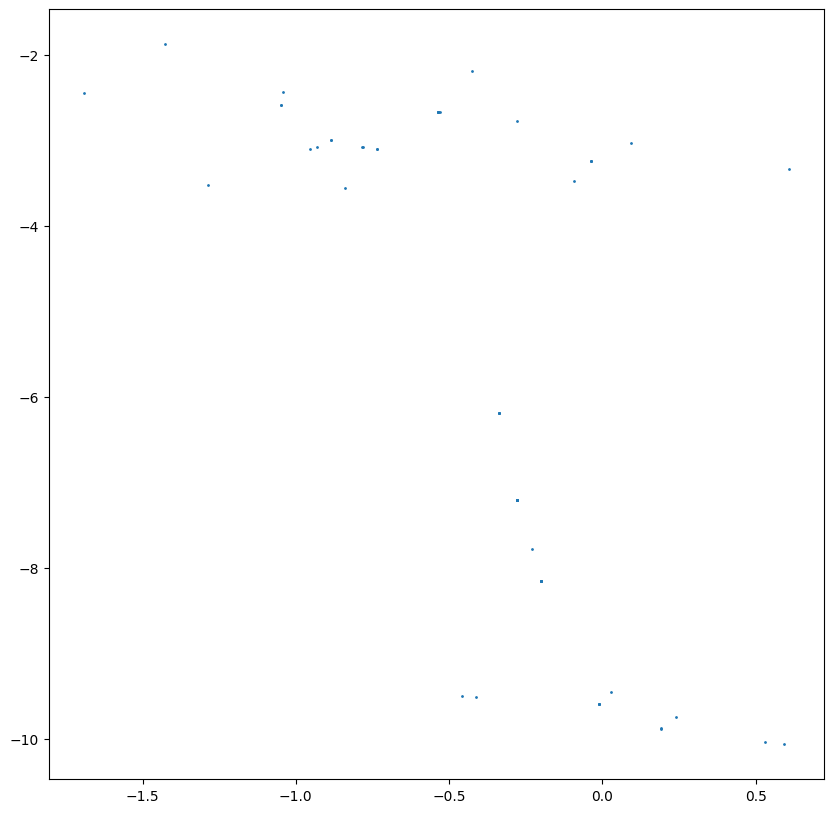

In [16]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

for batch in data:

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='random',
        max_iter=1000,
        verbose=1
    )

    X_2d = tsne.fit_transform(batch.detach().numpy())

    plt.figure(figsize=(10, 10))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], s=1)
    plt.show()
    break


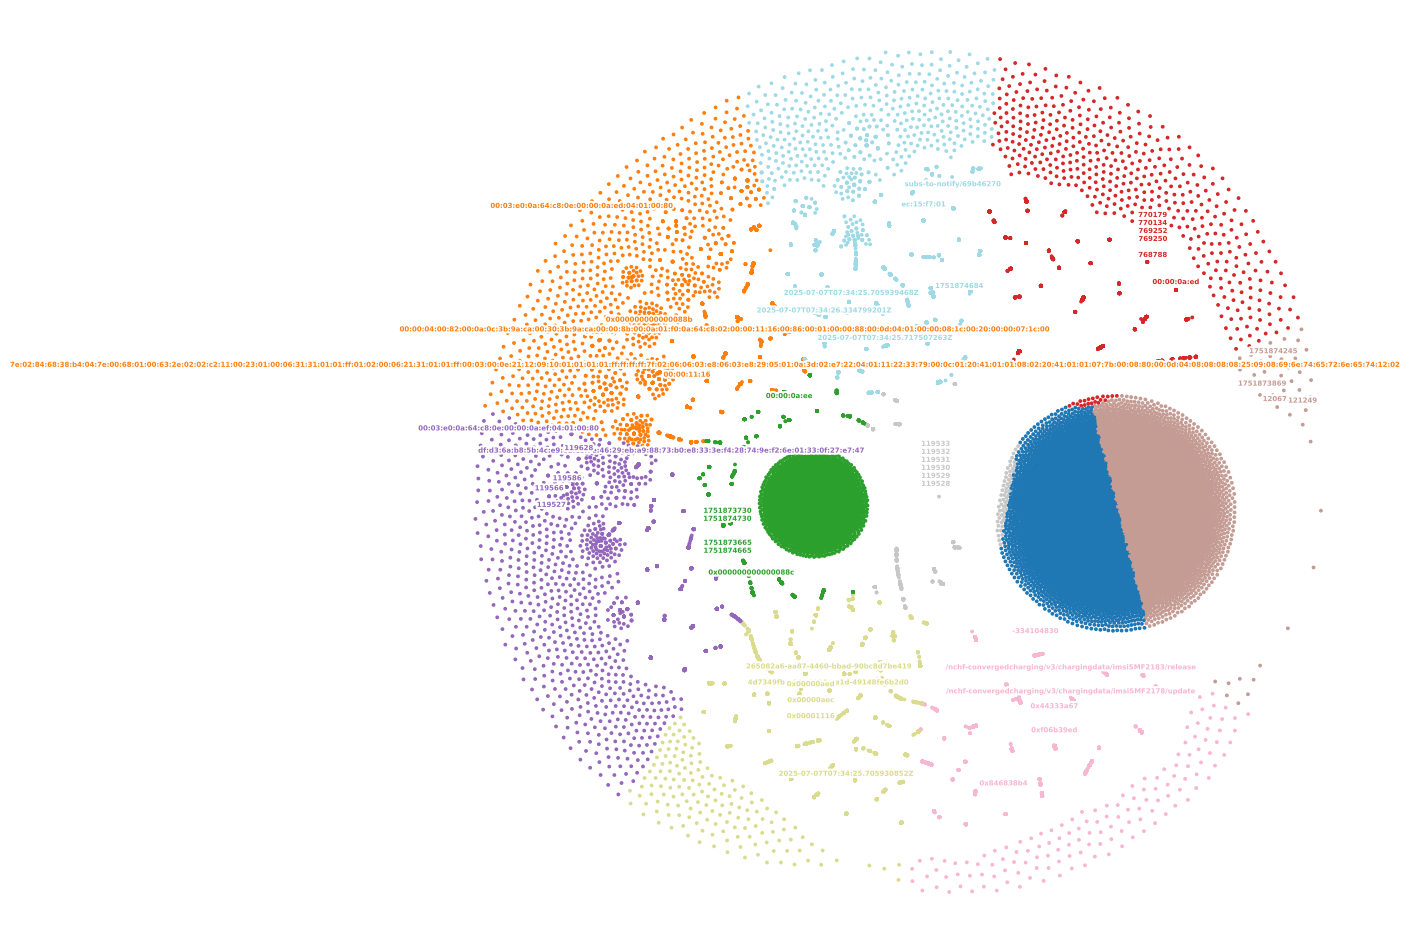

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import patheffects

# préparation des labels
labels = []
for label_list in batch.label:
    labels += label_list

# clustering
k = 10
kmeans = KMeans(n_clusters=k).fit(X_2d)
cluster_ids = kmeans.labels_

# colormap et palette correcte
cmap = plt.get_cmap("tab20")
palette = [cmap(i/(k-1)) for i in range(k)]  # normalisation [0,1]

plt.figure(figsize=(12, 12))

# scatter
point_colors = [palette[c] for c in cluster_ids]
plt.scatter(X_2d[:,0], X_2d[:,1], c=point_colors, s=3)

# nombre de labels par cluster
n_labels = 6

for c in range(k):
    pts = np.where(cluster_ids==c)[0]
    if len(pts)==0:
        continue
    centroid = kmeans.cluster_centers_[c]

    d = np.linalg.norm(X_2d[pts] - centroid, axis=1)
    # sorted_pts = pts[np.argsort(d)]

    # sélection jusqu'à n_labels avec label non nul
    selected = []
    for idx in pts:
        lbl = labels[idx]
        if lbl not in (None, "", [], 0):
            selected.append(idx)
        if len(selected) >= n_labels:
            break
    if len(selected)==0:
        continue

    cluster_color = palette[c]

    # annotation
    for i, idx in enumerate(selected):
        lbl = str(labels[idx])
        x, y = X_2d[idx]
        offset_y = i*2  # léger décalage pour ne pas superposer

        txt = plt.text(
            x, y+offset_y, lbl,
            fontsize=5,
            color=cluster_color,
            weight="bold",
            ha="center",
            va="center"
        )

        # bordure pour lisibilité
        txt.set_path_effects([
            patheffects.Stroke(linewidth=3, foreground="white"),
            patheffects.Normal()
        ])

plt.axis("off")
plt.show()
